# **COLMAP :**

NOTE : 
- database.db
    - COLMAP stores the extracted information here

- sparse_path
    - COLMAP's SfM/Mapper will save the sparse reconstruction here.

- dense_path
    - This is where the dense reconstruction workspace goes.

In [1]:
from pathlib import Path
import cv2
# Project paths
PROJECT_ROOT = Path("..")

VIDEO_PATH = PROJECT_ROOT / "video"
FRAMES_PATH = PROJECT_ROOT / "data" / "frames"

COLMAP_PATH = PROJECT_ROOT / "data" / "colmap"
DATABASE_PATH = COLMAP_PATH / "database.db"
SPARSE_PATH = COLMAP_PATH / "sparse"
DENSE_PATH = COLMAP_PATH / "dense"

# Create required directories
COLMAP_PATH.mkdir(parents=True, exist_ok=True)
SPARSE_PATH.mkdir(parents=True, exist_ok=True)
DENSE_PATH.mkdir(parents=True, exist_ok=True)

print("Frames :", FRAMES_PATH)
print("Database:", DATABASE_PATH)
print("Sparse :", SPARSE_PATH)
print("Dense  :", DENSE_PATH)

Frames : ..\data\frames
Database: ..\data\colmap\database.db
Sparse : ..\data\colmap\sparse
Dense  : ..\data\colmap\dense


In [2]:
# # * extracted frames
image_files = sorted(FRAMES_PATH.glob("*.jpg"))

print(f"Number of frames: {len(image_files)}")

if image_files:
    print(f"First frame: {image_files[0]}")
    print(f"Last frame : {image_files[-1]}")

Number of frames: 397
First frame: ..\data\frames\frame_000000.jpg
Last frame : ..\data\frames\frame_000396.jpg


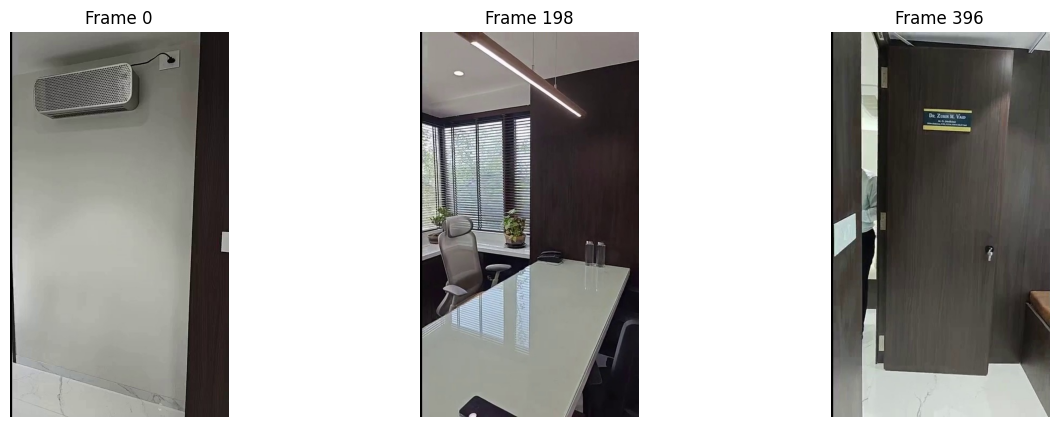

In [3]:
# # * looking into few images :

import matplotlib.pyplot as plt

indices = [0, len(image_files)//2, len(image_files)-1]

plt.figure(figsize=(15, 5))

for i, index in enumerate(indices):
    image = cv2.imread(str(image_files[index]))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Frame {index}")

plt.show()

# **Run Feature Extraction :**

In [4]:
import subprocess

In [ ]:
import subprocess

COLMAP = r"C:\Users\sejal\Downloads\colmap-x64-windows-cuda\bin\colmap.exe"
DATABASE_PATH = r"D:\3D Reconstruction - 2\data\colmap\database.db"
IMAGE_PATH = r"D:\3D Reconstruction - 2\data\frames"

command = [
    COLMAP,
    "feature_extractor",
    "--database_path", DATABASE_PATH,
    "--image_path", IMAGE_PATH,
    "--FeatureExtraction.use_gpu", "1",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)


I20260902 21:22:31.802672 26140 feature_extraction.cc:498] === Feature extraction ===
I20260902 21:22:31.804630  3476 sift.cc:759] Creating SIFT GPU feature extractor
I20260902 21:22:31.898601 20004 feature_extraction.cc:270] Processed file [1/397]
I20260902 21:22:31.898657 20004 feature_extraction.cc:273]   Name:            frame_000000.jpg
W20260902 21:22:31.898666 20004 feature_extraction.cc:277] frame_000000.jpg IMAGE_EXISTS: Features for image were already extracted.
I20260902 21:22:31.899087 20004 feature_extraction.cc:270] Processed file [2/397]
I20260902 21:22:31.899098 20004 feature_extraction.cc:273]   Name:            frame_000001.jpg
W20260902 21:22:31.899107 20004 feature_extraction.cc:277] frame_000001.jpg IMAGE_EXISTS: Features for image were already extracted.
I20260902 21:22:31.899132 20004 feature_extraction.cc:270] Processed file [3/397]
I20260902 21:22:31.899141 20004 feature_extraction.cc:273]   Name:            frame_000002.jpg
W20260902 21:22:31.899150 20004 fea

# **Run feature matching :**

In [6]:
command = [
    COLMAP,
    "sequential_matcher",
    "--database_path", DATABASE_PATH,
    "--FeatureMatching.use_gpu", "1",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"COLMAP matching failed with exit code {result.returncode}"
    )

print("Feature matching completed successfully.")


I20260902 21:22:32.072277 31692 feature_matching.cc:196] === Feature matching & geometric verification ===
I20260902 21:22:32.138498 31208 feature_matching_utils.cc:79] Bind FeatureMatcherWorker to GPU device 0
I20260902 21:22:32.139859 31208 sift.cc:1680] Creating SIFT GPU feature matcher
I20260902 21:22:32.140147 31692 pairing.cc:436] Generating sequential image pairs...
I20260902 21:22:32.141076 31692 pairing.cc:560] Processing image [1/397]
I20260902 21:22:32.141150 31692 feature_matching.cc:218] in 0.000s
I20260902 21:22:32.141163 31692 pairing.cc:560] Processing image [2/397]
I20260902 21:22:32.141202 31692 feature_matching.cc:218] in 0.000s
I20260902 21:22:32.141212 31692 pairing.cc:560] Processing image [3/397]
I20260902 21:22:32.141248 31692 feature_matching.cc:218] in 0.000s
I20260902 21:22:32.141257 31692 pairing.cc:560] Processing image [4/397]
I20260902 21:22:32.141298 31692 feature_matching.cc:218] in 0.000s
I20260902 21:22:32.141307 31692 pairing.cc:560] Processing imag

# **Sparse Reconstruction / Mapper :**

In [7]:
DATABASE_PATH = r"D:\3D Reconstruction - 2\data\colmap\database.db"
IMAGE_PATH = r"D:\3D Reconstruction - 2\data\frames"
SPARSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\sparse"

Path(SPARSE_PATH).mkdir(parents=True, exist_ok=True)

command = [
    COLMAP,
    "mapper",
    "--database_path", DATABASE_PATH,
    "--image_path", IMAGE_PATH,
    "--output_path", SPARSE_PATH,
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"COLMAP mapper failed with exit code {result.returncode}"
    )

print("Sparse reconstruction completed successfully.")


I20260902 21:22:32.292751 33624 incremental_pipeline.cc:353] Loading database
I20260902 21:22:32.293504 33624 database_cache.cc:73] Loading rigs...
I20260902 21:22:32.293748 33624 database_cache.cc:83]  397 in 0.000s
I20260902 21:22:32.293763 33624 database_cache.cc:91] Loading cameras...
I20260902 21:22:32.293892 33624 database_cache.cc:109]  397 in 0.000s
I20260902 21:22:32.293902 33624 database_cache.cc:117] Loading frames...
I20260902 21:22:32.294489 33624 database_cache.cc:127]  397 in 0.001s
I20260902 21:22:32.294518 33624 database_cache.cc:135] Loading matches...
I20260902 21:22:32.302514 33624 database_cache.cc:140]  2346 in 0.008s
I20260902 21:22:32.302577 33624 database_cache.cc:148] Loading images...
I20260902 21:22:32.313707 33624 database_cache.cc:245]  397 in 0.011s (connected 397, loaded 397)
I20260902 21:22:32.313754 33624 database_cache.cc:259] Loading pose priors...
I20260902 21:22:32.313770 33624 database_cache.cc:267]  0 in 0.000s
I20260902 21:22:32.313781 33624 da

In [10]:
from pathlib import Path

sparse_model = Path("../data/colmap/sparse/0")

print("Sparse model exists:", sparse_model.exists())

if sparse_model.exists():
    for file in sparse_model.iterdir():
        print(file.name)

Sparse model exists: True
cameras.bin
frames.bin
images.bin
points3D.bin
project.ini
rigs.bin


In [9]:
stop

NameError: name 'stop' is not defined

In [11]:
import os

len(os.listdir(SPARSE_PATH))

7

In [12]:
import subprocess
from pathlib import Path

COLMAP = r"C:\Users\sejal\Downloads\colmap-x64-windows-cuda\bin\colmap.exe"

SPARSE_PATH = Path("../data/colmap/sparse")
TXT_ROOT = Path("../data/colmap/sparse_txt")

TXT_ROOT.mkdir(parents=True, exist_ok=True)


def get_model_stats(model_id):
    model_path = SPARSE_PATH / str(model_id)
    txt_path = TXT_ROOT / str(model_id)

    txt_path.mkdir(parents=True, exist_ok=True)

    command = [
        COLMAP,
        "model_converter",
        "--input_path", str(model_path.resolve()),
        "--output_path", str(txt_path.resolve()),
        "--output_type", "TXT",
    ]

    result = subprocess.run(
        command,
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr)
        return None

    # Count registered images
    images_file = txt_path / "images.txt"
    points_file = txt_path / "points3D.txt"

    with open(images_file, "r") as f:
        image_lines = [
            line for line in f
            if line.strip() and not line.startswith("#")
        ]

    # Each image uses two lines in images.txt
    registered_images = len(image_lines) // 2

    # Count 3D points
    with open(points_file, "r") as f:
        point_lines = [
            line for line in f
            if line.strip() and not line.startswith("#")
        ]

    num_points = len(point_lines)

    return registered_images, num_points


best_model_id=0
best_num_points=0
best_num_image=0

for model_id in range(len(os.listdir(SPARSE_PATH))):
    stats = get_model_stats(model_id)

    if stats:
        registered_images, num_points = stats

        if num_points > best_num_points :
            best_num_points=num_points
            best_model_id=model_id
            best_num_image=registered_images

        print(
            f"Model {model_id}: "
            f"{registered_images} images, "
            f"{num_points} 3D points"
        )



print("="*20)
print(
    f"Best Model : { best_model_id} \n"
    f"Best num Points :{best_num_points}\n"
    f"Best Register Image :{best_num_image}\n"
)

Model 0: 9 images, 11 3D points
Model 1: 360 images, 8557 3D points
Model 2: 12 images, 14 3D points
Model 3: 31 images, 51 3D points
Model 4: 125 images, 2108 3D points
Model 5: 69 images, 868 3D points
Model 6: 54 images, 671 3D points
Best Model : 1 
Best num Points :8557
Best Register Image :360



## **Convert sparse model to PLY :**

- COLMAP's points3D.bin is its internal format. For visualization and our final deliverable, we want a .ply.

In [13]:
SPARSE_MODEL = rf"D:\3D Reconstruction\data\colmap\sparse\{best_model_id}"
SPARSE_MODEL

'D:\\3D Reconstruction\\data\\colmap\\sparse\\1'

In [15]:
SPARSE_MODEL = rf"D:\3D Reconstruction - 2\data\colmap\sparse\{best_model_id}"

SPARSE_PLY = r"D:\3D Reconstruction - 2\data\colmap\sparse.ply"

command = [
    COLMAP,
    "model_converter",
    "--input_path", SPARSE_MODEL,
    "--output_path", SPARSE_PLY,
    "--output_type", "PLY",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"Sparse model conversion failed: {result.returncode}"
    )

print(f"Sparse point cloud saved to: {SPARSE_PLY}")



Sparse point cloud saved to: D:\3D Reconstruction - 2\data\colmap\sparse.ply


In [16]:
from pathlib import Path

sparse_ply = Path("../data/colmap/sparse.ply")

print("Exists:", sparse_ply.exists())
print("Size:", sparse_ply.stat().st_size, "bytes")

Exists: True
Size: 128543 bytes


In [ ]:
!pip install open3d

In [17]:
import open3d as o3d

pcd = o3d.io.read_point_cloud("../data/colmap/sparse.ply")

print(pcd)
print("Number of points:", len(pcd.points))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
PointCloud with 8557 points.
Number of points: 8557


# **Dense Reconstruction :**

In [19]:
from pathlib import Path

DENSE_PATH = Path("../data/colmap/dense")

DENSE_PATH.mkdir(parents=True, exist_ok=True)

print("Dense workspace:", DENSE_PATH.resolve())

Dense workspace: D:\3D Reconstruction - 2\data\colmap\dense


In [20]:
import subprocess


IMAGE_PATH = r"D:\3D Reconstruction - 2\data\frames"

SPARSE_MODEL = rf"D:\3D Reconstruction - 2\data\colmap\sparse\{best_model_id}"

SPARSE_PLY = r"D:\3D Reconstruction - 2\data\colmap\sparse.ply"

DENSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\dense"

command = [
    COLMAP,
    "image_undistorter",
    "--image_path", IMAGE_PATH,
    "--input_path", SPARSE_MODEL,
    "--output_path", DENSE_PATH,
    "--output_type", "COLMAP",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"Image undistortion failed: {result.returncode}"
    )

print("Image undistortion completed successfully.")


I20260902 21:33:24.168449 31404 image.cc:377] === Reading reconstruction ===
I20260902 21:33:24.218391 31404 image.cc:380] => Reconstruction with 360 images and 8557 points
I20260902 21:33:24.218471 31404 undistorters.cc:167] === Image undistortion ===
I20260902 21:33:24.220619 31404 undistorters.cc:209] Undistorting image [1/360]
I20260902 21:33:24.281292 31404 undistorters.cc:209] Undistorting image [2/360]
I20260902 21:33:24.282548 31404 undistorters.cc:209] Undistorting image [3/360]
I20260902 21:33:24.282587 31404 undistorters.cc:209] Undistorting image [4/360]
I20260902 21:33:24.282601 31404 undistorters.cc:209] Undistorting image [5/360]
I20260902 21:33:24.282613 31404 undistorters.cc:209] Undistorting image [6/360]
I20260902 21:33:24.282625 31404 undistorters.cc:209] Undistorting image [7/360]
I20260902 21:33:24.282637 31404 undistorters.cc:209] Undistorting image [8/360]
I20260902 21:33:24.282648 31404 undistorters.cc:209] Undistorting image [9/360]
I20260902 21:33:24.305984 

# **PatchMatch Stereo :**

In [21]:
import subprocess


DENSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\dense"

command = [
    COLMAP,
    "patch_match_stereo",
    "--workspace_path", DENSE_PATH,
    "--workspace_format", "COLMAP",
    "--PatchMatchStereo.geom_consistency", "true",
    "--PatchMatchStereo.gpu_index", "0",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"PatchMatch Stereo failed with exit code {result.returncode}"
    )

print("PatchMatch Stereo completed successfully.")


I20260902 21:33:35.889862 12512 patch_match.cc:210] Reading workspace...
I20260902 21:33:35.946100 12512 patch_match.cc:240] Reading configuration...
I20260902 21:33:36.411569 12512 patch_match.cc:371] Configuration has 360 problems...
I20260902 21:33:36.414609 22348 patch_match.cc:419] === Processing view 1 / 360 for frame_000037.jpg ===
I20260902 21:33:36.414783 22348 patch_match.cc:466] Reading inputs...
I20260902 21:33:36.439554 22348 patch_match.cc:56] --- PatchMatch::Problem ---
I20260902 21:33:36.439618 22348 patch_match.cc:57] ref_image_idx: 0
I20260902 21:33:36.439631 22348 patch_match.cc:64] src_image_idxs: 5 13 12 10 11 19 20 21 39 33 9 16 6 8 14 17 18 7 15 22
I20260902 21:33:36.439638 22348 patch_match_options.cc:46] --- PatchMatchOptions ---
I20260902 21:33:36.439647 22348 patch_match_options.cc:47] max_image_size: -1
I20260902 21:33:36.439654 22348 patch_match_options.cc:48] gpu_index: 0
I20260902 21:33:36.439659 22348 patch_match_options.cc:49] depth_min: 8.70165
I20260

# **COLMAP dense-reconstruction step: Stereo Fusion :**

In [22]:
import subprocess


DENSE_PATH = r"D:\3D Reconstruction - 2\data\colmap\dense"

command = [
    COLMAP,
    "stereo_fusion",
    "--workspace_path", DENSE_PATH,
    "--workspace_format", "COLMAP",
    "--output_path", DENSE_PATH + r"\fused.ply",
]

result = subprocess.run(
    command,
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        f"Stereo Fusion failed with exit code {result.returncode}"
    )

print("Dense point cloud created successfully.")
print("Output:", DENSE_PATH + r"\fused.ply")


I20260902 22:28:07.319659 29028 fusion.cc:79] --- StereoFusion::Options ---
I20260902 22:28:07.320672 29028 fusion.cc:80] mask_path: ""
I20260902 22:28:07.320693 29028 fusion.cc:81] max_image_size: -1
I20260902 22:28:07.320705 29028 fusion.cc:82] min_num_pixels: 5
I20260902 22:28:07.320717 29028 fusion.cc:83] max_num_pixels: 10000
I20260902 22:28:07.320728 29028 fusion.cc:84] max_traversal_depth: 100
I20260902 22:28:07.320737 29028 fusion.cc:85] max_reproj_error: 2
I20260902 22:28:07.320752 29028 fusion.cc:86] max_depth_error: 0.01
I20260902 22:28:07.320763 29028 fusion.cc:87] max_normal_error: 10
I20260902 22:28:07.320774 29028 fusion.cc:88] check_num_images: 50
I20260902 22:28:07.320784 29028 fusion.cc:89] use_cache: 0
I20260902 22:28:07.320795 29028 fusion.cc:90] cache_size: 32
I20260902 22:28:07.320806 29028 fusion.cc:93] bbox_min: -3.40282e+38 -3.40282e+38 -3.40282e+38
I20260902 22:28:07.320832 29028 fusion.cc:94] bbox_max: 3.40282e+38 3.40282e+38 3.40282e+38
I20260902 22:28:07.3

In [29]:
path_dens=r"D:\3D Reconstruction - 2\src\results\colmap\exp_02_25fps_baseline\dense.ply"

In [30]:
import open3d as o3d


# dense_pcd = o3d.io.read_point_cloud(
#     "../results/colmap/exp_30fps_exp1/fused.ply"
# )
dense_pcd = o3d.io.read_point_cloud(
    path_dens
)

print(dense_pcd)
print("Dense points:", len(dense_pcd.points))

PointCloud with 108935 points.
Dense points: 108935


In [31]:
o3d.visualization.draw_geometries([dense_pcd])